In [1]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras

from tensorflow.keras import layers, models


2025-11-13 05:01:55.612346: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-13 05:01:55.612419: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-13 05:01:55.613514: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-13 05:01:55.620467: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-13 05:01:57.463055: W tensorflow/compiler/tf2

In [2]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer

pi = 3.14159265359

maxval=1e9
minval=1e-9

In [3]:
# Trasformer model

class PatchExtractor(layers.Layer):
  """Extract 2D patches from images."""
  def __init__(self, patch_size=(3,7)):
    super().__init__()
    self.patch_size = patch_size

  def call(self, images):
    # images: (batch, H, W, C)
    patch_h, patch_w = self.patch_size
    batch_size = tf.shape(images)[0]
    patches = tf.image.extract_patches(
        images=images,
        sizes=(1, patch_h, patch_w, 1),
        strides=(1, patch_h, patch_w, 1),
        rates=(1,1,1,1),
        padding='VALID'
    )
    # Now `patches` has shape: 
    #   (batch, H//patch_h, W//patch_w, patch_h*patch_w*C)
    # Flatten the 2D grid of patches => (batch, num_patches, patch_dim)
    patch_dims = tf.shape(patches)[-1]
    patches = tf.reshape(
        patches,
        [batch_size, -1, patch_dims]
    )
    return patches

class PatchEncoder(layers.Layer):
  """Linear embedding + learnable positional encoding."""
  def __init__(self, num_patches, embed_dim):
    super().__init__()
    self.num_patches = num_patches
    self.projection  = layers.Dense(embed_dim)
    self.pos_embed   = tf.Variable(
        initial_value=tf.zeros((1,num_patches,embed_dim)),
        trainable=True,
        name="pos_embedding"
    )

  def call(self, patch_batch):
    # Linear projection of patch tokens
    projected = self.projection(patch_batch)
    # Add learnable positional embeddings
    return projected + self.pos_embed

def transformer_encoder(inputs,
                        head_size,
                        num_heads,
                        ff_dim,
                        dropout=0.1):
  # LayerNorm + Multi-head attention
  x = layers.LayerNormalization(epsilon=1e-6)(inputs)
  x = layers.MultiHeadAttention(num_heads=num_heads,
                                key_dim=head_size,
                                dropout=dropout)(x, x)
  x = layers.Dropout(dropout)(x)
  res = x + inputs
  
  # Next LN + feed-forward
  x = layers.LayerNormalization(epsilon=1e-6)(res)
  x = layers.Dense(ff_dim, activation="relu")(x)
  x = layers.Dropout(dropout)(x)
  x = layers.Dense(inputs.shape[-1], activation="linear")(x)
  x = layers.Dropout(dropout)(x)
  
  return x + res

def create_vit_model(input_shape=(13,21,2),
                     patch_size=(3,7),
                     embed_dim=64,
                     num_heads=4,
                     ff_dim=128,
                     num_layers=4,
                     dropout=0.1,
                     final_outputs=14):
  # Input
  inp = layers.Input(shape=input_shape, name="raw_input")

  q_out = SoftQuantizeLayer(
      n_bits=2,
    initial_levels=np.array([0.0, 1.0, 2.0, 3.0], dtype=np.float32),
      threshold_offset=80,
      initial_thresholds=[629.6, 1121.1, 2056.3],
      trainable_levels=False,
      trainable_thresholds=True,
      initial_k=1.0,
      trainable_k=True,
      name="soft_quantizer_output"
  )(inp)

  # 1) Extract patches
  patches = PatchExtractor(patch_size=patch_size)(q_out)
  
  # Calculate how many patches we extracted:
  #   (H // patch_h) * (W // patch_w)
  # Must do it statically if possible:
  # e.g. 13//3=4, 21//7=3 => 12 patches total
  H, W, C = input_shape
  ph, pw  = patch_size
  num_patches = (H // ph) * (W // pw)

  # 2) Encode patches (linear projection + positional embedding)
  encoded_patches = PatchEncoder(num_patches, embed_dim)(patches)

  # 3) Apply multiple Transformer encoder blocks
  x = encoded_patches
  for _ in range(num_layers):
    x = transformer_encoder(x,
                            head_size=embed_dim,
                            num_heads=num_heads,
                            ff_dim=ff_dim,
                            dropout=dropout)
  
  # 4) Flatten and final Dense
  x = layers.LayerNormalization(epsilon=1e-6)(x)
  x = layers.Flatten()(x)
  x = layers.Dense(64, activation='relu')(x)
  outputs = layers.Dense(final_outputs, activation='linear')(x)

  # Create model
  model = keras.Model(inputs=inp, outputs=outputs)
  return model

model = create_vit_model(
    input_shape=(16,16,2),   
    patch_size=(3,4),        
    embed_dim=64,           
    num_heads=4,            
    ff_dim=128,              
    num_layers=4,            
    dropout=0.1,             
    final_outputs=14         
)

2025-11-13 05:02:05.918398: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38397 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB MIG 7g.40gb, pci bus id: 0000:21:00.0, compute capability: 8.0
2025-11-13 05:02:06.376218: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 raw_input (InputLayer)      [(None, 16, 16, 2)]          0         []                            
                                                                                                  
 soft_quantizer_output (Sof  (None, 16, 16, 2)            4         ['raw_input[0][0]']           
 tQuantizeLayer)                                                                                  
                                                                                                  
 patch_extractor (PatchExtr  (None, None, 24)             0         ['soft_quantizer_output[0][0]'
 actor)                                                             ]                             
                                                                                              

In [6]:
NOISE_MU = 0.0
NOISE_SIGMA = 80.0 # e-

In [7]:
import glob
import re

# models_base_dir = f"/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr"
# models_base_dir = f"/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig"

models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_{NOISE_MU}mu_{NOISE_SIGMA}sig_NoLog_Stdr_4p0'
# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf0.0_ThL0.0_ThH120.0'
# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf400.0_ThL400.0_ThH2200.0'
# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf2000.0_ThL2000.0_ThH2200.0'



# models_base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/largerWindowPreliminary/dataset_3sr_16x16_50x12P5_centeredIncidence_parquets/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0_ThOf80.0_ThL80.0_ThH2200.0'


dirs = glob.glob(os.path.join(models_base_dir, "Transformer_model-*-checkpoints"))
fingerprint_list = []
for d in dirs:
    m = re.search(r"Transformer_model-([a-f0-9]+)-checkpoints$", os.path.basename(d))
    if m:
        fingerprint_list.append(m.group(1))

print(fingerprint_list)


['06e9d69b', '2eef8a21', '5512f272', '1b3eb4c0', '8b902f5c', 'df3576e1', 'bf9385c2', 'b86c56aa', '747dd304', 'f7093404', '14af2de3', '848c0897', 'd2560da0', '88348cd5', '6d008cb4', '935019d2', '331f69d9', '843ca551', '3e6d132d', '20b60499', '1ac54186', 'a603a1e4', '18a5a944']


In [15]:
fingerprint = "5512f272"

In [16]:
base_dir = os.path.join(models_base_dir, f"Transformer_model-{fingerprint}-checkpoints")
plot_dir = os.path.join(base_dir, 'plots')
checkpoints_dir = os.path.join(base_dir, 'checkpoints')
training_cp_path = os.path.join(base_dir, 'training_log.csv')
training_history = pd.read_csv(training_cp_path)

os.makedirs(plot_dir, exist_ok=True)

checkpoint_files = sorted([os.path.join(checkpoints_dir, f) for f in os.listdir(checkpoints_dir) if f.endswith('.hdf5')])
# checkpoint_files

def extract_val_metric(fname):
    try:
        val_str = fname.split("-v-")[-1].replace(".hdf5", "")
        return float(val_str)
    except Exception:
        return float("-inf")

best_ckpt = None
best_val = float("-inf")

for f in checkpoint_files:
    val = extract_val_metric(os.path.basename(f))
    if val > best_val:
        best_val = val
        best_ckpt = f

print(f"Loading model from {best_ckpt}")
model.load_weights(best_ckpt)

Loading model from /home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/2t_N_rnd_thr_0.0mu_80.0sig_NoLog_Stdr_4p0/Transformer_model-5512f272-checkpoints/checkpoints/weights.889-t-42640.21-v-44567.75.hdf5


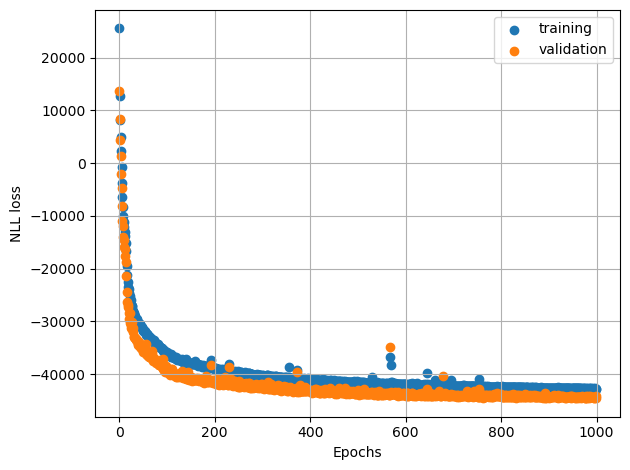

In [17]:
plt.scatter(training_history['epoch'], training_history['loss'])
plt.scatter(training_history['epoch'], training_history['val_loss'])
plt.legend(['training', 'validation'])
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('NLL loss')
plt.tight_layout() 
plt.show()

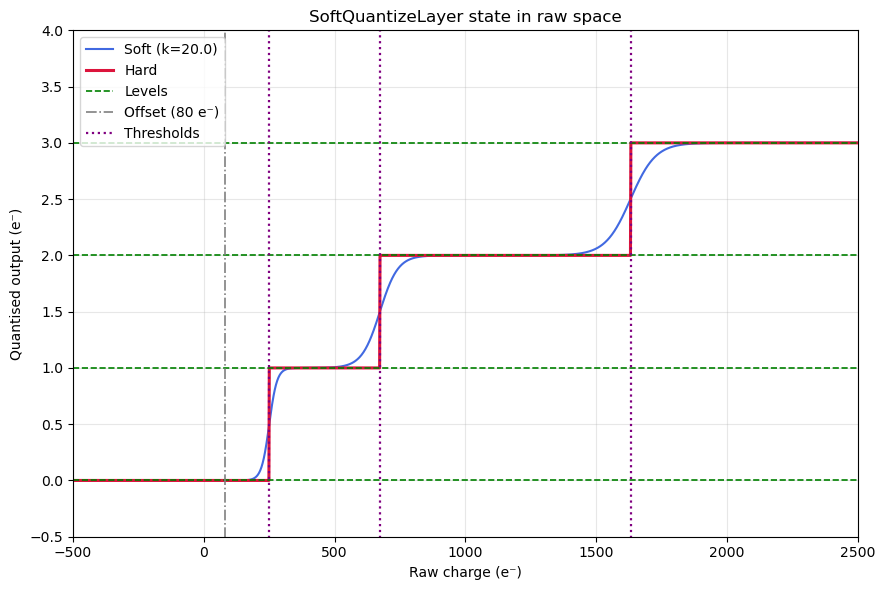

In [55]:
# --- grab the layer once ---
sq_layer = model.get_layer("soft_quantizer_output")

# 1. use the actual k in the layer, not the hard-coded 61
k_now = float(sq_layer.k.numpy())
k_now = 20
# 2. pick a sensible raw-charge domain
#    your thresholds sit ~600-2050 e⁻, so let’s visualise −500→2500 e⁻
x_min, x_max = -500.0, 2500.0
x_input = tf.linspace(x_min, x_max, 2000)          # (N,)

# 3. get state in *raw* units (already the case)
levels      = sq_layer.levels.numpy()              # shape (4,)
threshold_offset = sq_layer.threshold_offset
thresholds  = sq_layer.thresholds.numpy()          # shape (3,)
tau = sq_layer.tau.numpy()

# 4. quantise
y_hard = sq_layer._hard_quantize(x_input, levels, thresholds)
y_soft = sq_layer._soft_quantize(x_input, k_now, levels, thresholds, tau)

# 5. quick plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(x_input, y_soft,  color="royalblue",  label=f"Soft (k={k_now:.1f})")
ax.plot(x_input, y_hard,  color="crimson",    lw=2.2, label="Hard")

ax.hlines(levels,     x_min, x_max, colors="green",  ls="--", lw=1.2, label="Levels")
ax.vlines(threshold_offset, ymin=levels.min()-100, ymax=levels.max()+100,
          colors='grey', ls='-.', lw=1.2, label='Offset (80 e⁻)')
ax.vlines(thresholds, levels.min()-100, levels.max()+100,
          colors="purple", ls=":", lw=1.6, label="Thresholds")

ax.set_xlim(x_min, x_max)
ax.set_ylim(levels.min()-200, levels.max()+200)

ax.set_xlabel("Raw charge (e⁻)")
ax.set_ylabel("Quantised output (e⁻)")
ax.set_title("SoftQuantizeLayer state in raw space")
ax.grid(True, alpha=.3)
ax.legend()
plt.tight_layout()
plt.ylim([-0.5, +4.0])
plt.savefig(
    "SoftQuant.png",   # or .svg / .pdf for vector
    dpi=300,                    # high resolution
    # bbox_inches='tight',       # remove excess whitespace
)
plt.show()


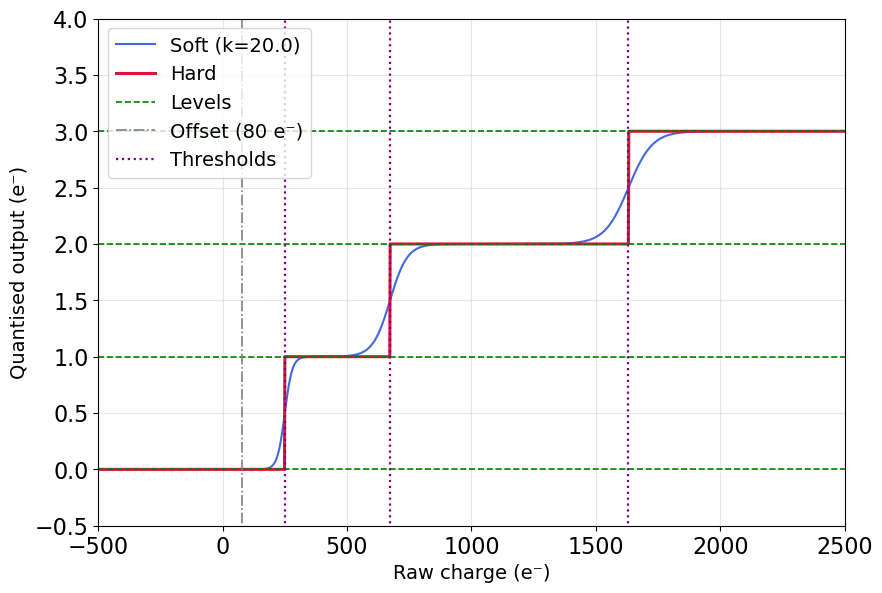

In [58]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(x_input, y_soft,  color="royalblue",  label=f"Soft (k={k_now:.1f})")
ax.plot(x_input, y_hard,  color="crimson",    lw=2.2, label="Hard")

ax.hlines(levels,     x_min, x_max, colors="green",  ls="--", lw=1.2, label="Levels")
ax.vlines(threshold_offset, ymin=levels.min()-100, ymax=levels.max()+100,
          colors='grey', ls='-.', lw=1.2, label='Offset (80 e⁻)')
ax.vlines(thresholds, levels.min()-100, levels.max()+100,
          colors="purple", ls=":", lw=1.6, label="Thresholds")

ax.set_xlim(x_min, x_max)
ax.set_ylim(levels.min()-200, levels.max()+200)

ax.set_xlabel("Raw charge (e⁻)", fontsize=14)
ax.set_ylabel("Quantised output (e⁻)", fontsize=14)
# ax.set_title("SoftQuantizeLayer state in raw space", fontsize=20)

ax.tick_params(axis='both', labelsize=16)
ax.grid(True, alpha=.3)
ax.legend(fontsize=14)

plt.tight_layout()
plt.ylim([-0.5, +4.0])
plt.savefig(
    "SoftQuant.png",
    dpi=300,
)
plt.show()


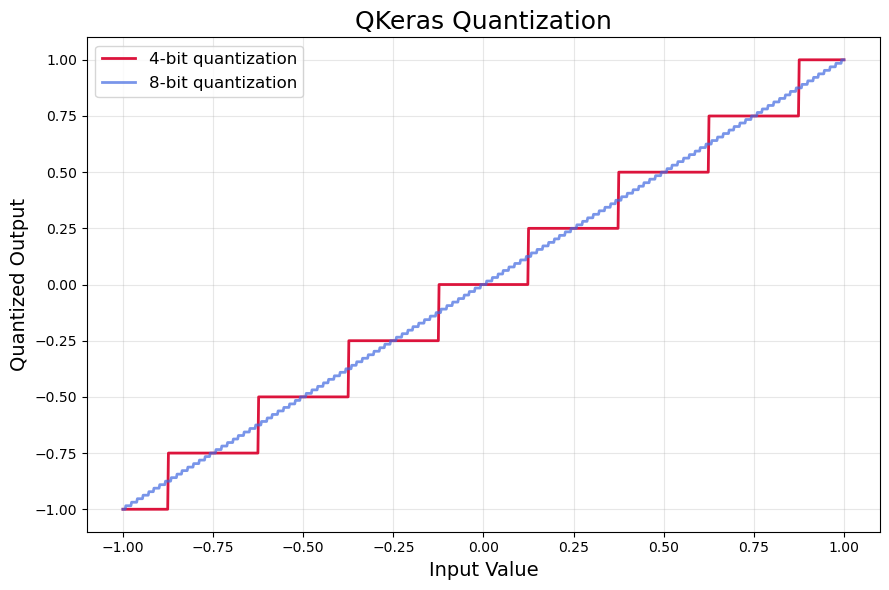

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from qkeras.quantizers import quantized_bits

# Range to quantize
x = np.linspace(-1, 1, 1000)

# Define quantizers
q_4bit = quantized_bits(bits=4, integer=1, keep_negative=True)(x.astype(np.float32))
q_8bit = quantized_bits(bits=8, integer=1, keep_negative=True)(x.astype(np.float32))

# Plot
plt.figure(figsize=(9, 6))
plt.plot(x, q_4bit, label="4-bit quantization", lw=2, color='crimson')
plt.plot(x, q_8bit, label="8-bit quantization", lw=2, color='royalblue', alpha=0.7)

plt.title("QKeras Quantization", fontsize=18)
plt.xlabel("Input Value", fontsize=14)
plt.ylabel("Quantized Output", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()

# Save slide-ready version
plt.savefig("quantization_4bit_vs_8bit.png", dpi=300, transparent=True)
plt.show()


1/1 [==============================] - 0s 58ms/step


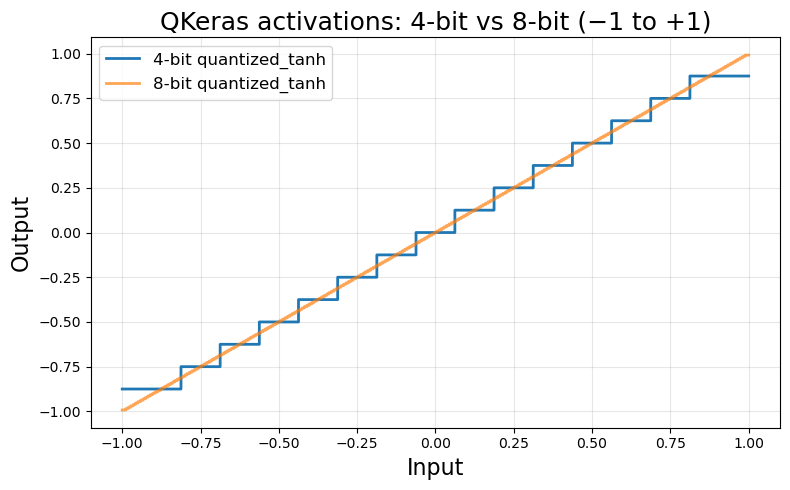

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from qkeras import QActivation

# -------------------------------------------------------
# 1) Build tiny 1D models with your activations
# -------------------------------------------------------
# 4-bit quantized_tanh(4, 0, 1)
x4 = tf.keras.Input(shape=(1,))
y4 = QActivation("quantized_tanh(4, 0, 1)")(x4)
model_4bit = tf.keras.Model(x4, y4)

# 8-bit quantized_tanh(8, 0, 1)
x8 = tf.keras.Input(shape=(1,))
y8 = QActivation("quantized_tanh(8, 0, 1)")(x8)
model_8bit = tf.keras.Model(x8, y8)

# -------------------------------------------------------
# 2) Evaluate on a dense grid in [-1, 1]
# -------------------------------------------------------
x = np.linspace(-1.0, 1.0, 2000, dtype=np.float32).reshape(-1, 1)

y_4bit = model_4bit.predict(x, batch_size=4096).squeeze()
y_8bit = model_8bit.predict(x, batch_size=4096).squeeze()

# -------------------------------------------------------
# 3) Plot for slides
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.step(x.squeeze(), y_4bit, where="mid", lw=2, label="4-bit quantized_tanh")
ax.step(x.squeeze(), y_8bit, where="mid", lw=2, alpha=0.7, label="8-bit quantized_tanh")

ax.set_xlabel("Input", fontsize=16)
ax.set_ylabel("Output", fontsize=16)
ax.set_title("QKeras activations: 4-bit vs 8-bit (−1 to +1)", fontsize=18)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("qkeras_quantized_tanh_4bit_vs_8bit.png", dpi=300)
plt.show()


In [34]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from tqdm.auto import tqdm

def save_history_animation(
    training_history,
    out_path="loss_history.gif",
    fps=8,
    dpi=150,
    frame_step=1,
    epochs_per_second=None,           # <<< NEW
    debug_first_frame_png=None        # e.g. "debug_loss_frame0.png"
):
    if training_history is None or training_history.empty:
        raise ValueError("training_history is empty; nothing to animate.")

    for col in ["epoch", "loss", "val_loss"]:
        if col not in training_history.columns:
            raise ValueError(f"Required column missing in training_history: {col}")

    df_h = training_history.sort_values("epoch").reset_index(drop=True)

    epochs = df_h["epoch"].to_numpy(dtype=float)
    loss = df_h["loss"].to_numpy(dtype=float)
    val_loss = df_h["val_loss"].to_numpy(dtype=float)

    # finite epoch range
    epochs_finite = epochs[np.isfinite(epochs)]
    if epochs_finite.size == 0:
        raise ValueError("No finite epoch values in training_history.")

    e_min = float(np.nanmin(epochs_finite))
    e_max = float(np.nanmax(epochs_finite))

    # X-limits (epochs)
    if e_max <= e_min:
        e_max = e_min + 1.0
    pad_x = 0.02 * (e_max - e_min)
    xlim = (e_min - pad_x, e_max + pad_x)

    # Y-limits from both loss + val_loss
    vals = np.concatenate([loss, val_loss])
    finite_vals = vals[np.isfinite(vals)]
    if finite_vals.size >= 2:
        ymin = float(np.nanmin(finite_vals))
        ymax = float(np.nanmax(finite_vals))
        if ymax <= ymin:
            ymax = ymin + 1.0
        pad_y = 0.1 * (ymax - ymin)
        ylim = (ymin - pad_y, ymax + pad_y)
    elif finite_vals.size == 1:
        y0 = float(finite_vals[0])
        ylim = (y0 - 1.0, y0 + 1.0)
    else:
        ylim = (0.0, 1.0)

    # CHANGE: Map epochs_per_second → fps and frame_step, same as save_epoch_animation.
    # REASON: Ensure temporal progression matches your threshold GIF when using same epochs_per_second.
    if epochs_per_second is not None:
        target_fps = max(1, min(30, int(round(min(epochs_per_second, 30)))))
        step = max(1, int(math.ceil(epochs_per_second / target_fps)))
        fps = max(1, min(50, int(round(epochs_per_second / step))))
        frame_step = step

    fig, ax = plt.subplots(1, 1, figsize=(9, 6), dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    train_line, = ax.plot([], [], "o", ms=4.5, alpha=0.85, label="training")
    val_line,   = ax.plot([], [], "s", ms=4.5, alpha=0.85, label="validation")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("NLL loss")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="best")
    fig.tight_layout()

    # Explicit vertical line at "current" epoch
    epoch_line, = ax.plot(
        [xlim[0], xlim[0]],
        [ylim[0], ylim[1]],
        ls="--",
        color="k",
        lw=1.4,
        alpha=0.9
    )

    # CHANGE: Build integer epoch frames to match the epoch-based time base.
    # REASON: Epoch-wise progression (in integers) is what you used in save_epoch_animation.
    step = max(1, int(frame_step))
    start_e = int(math.floor(e_min))
    end_e   = int(math.ceil(e_max))
    frames = list(range(start_e, end_e + 1, step))
    if frames[-1] != end_e:
        frames.append(end_e)

    def update(e):
        mask = epochs <= e
        train_line.set_data(epochs[mask], loss[mask])
        val_line.set_data(epochs[mask], val_loss[mask])
        epoch_line.set_data([e, e], [ylim[0], ylim[1]])
        return [train_line, val_line, epoch_line]

    if debug_first_frame_png:
        update(frames[0])
        fig.savefig(debug_first_frame_png, facecolor="white", edgecolor="none", dpi=dpi)

    out_dir = os.path.dirname(out_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    anim = FuncAnimation(fig, update, frames=frames, interval=1000 / fps, blit=False, repeat=False)

    ext = out_path.split(".")[-1].lower()
    if ext == "gif":
        writer = PillowWriter(fps=fps)
    elif ext in ("mp4", "m4v"):
        writer = FFMpegWriter(fps=fps, codec="libx264", bitrate=1800)
    else:
        plt.close(fig)
        raise ValueError("out_path must end with .gif or .mp4")

    pbar = tqdm(total=len(frames), desc="Rendering loss frames", unit="frame")

    def _progress(i, n):
        pbar.total = n
        pbar.n = i + 1
        pbar.refresh()

    anim.save(
        out_path,
        writer=writer,
        dpi=dpi,
        progress_callback=_progress,
        savefig_kwargs={"facecolor": "white", "edgecolor": "none"}
    )
    pbar.close()
    plt.close(fig)


In [36]:
save_history_animation(
    training_history,
    out_path="GIF/loss_history.gif",
    epochs_per_second=400,   # <<< same as save_epoch_animation
    dpi=150,
)


Rendering loss frames:   0%|          | 0/73 [00:00<?, ?frame/s]

In [37]:
training_log = os.path.join(base_dir, "training_log.csv")
quantizer_log = os.path.join(base_dir, "soft_quantizer_state_log.csv")

training_df = pd.read_csv(training_log)
quant_df = pd.read_csv(quantizer_log)

df = training_df.copy()
df["fingerprint"] = fingerprint
df["best_val_metric"] = best_val

for col in quant_df.columns:
    df[f"quantizer_{col}"] = quant_df[col].values

df.head()

,epoch,loss,val_loss,fingerprint,best_val_metric,quantizer_epoch,quantizer_k,quantizer_level_0,quantizer_level_1,quantizer_level_2,quantizer_level_3,quantizer_threshold_0,quantizer_threshold_1,quantizer_threshold_2
0,0,25513.468750,13693.577148,5512f272,44567.75,0,0.997757,0.0,1.0,2.0,3.0,326.85965,1614.0634,1766.4355
1,1,12760.821289,8385.652344,5512f272,44567.75,1,1.000924,0.0,1.0,2.0,3.0,327.04280,1615.1523,1763.5049
2,2,8076.754883,4296.782227,5512f272,44567.75,2,1.001150,0.0,1.0,2.0,3.0,327.15662,1615.7616,1757.3570
3,3,5017.069336,1433.244995,5512f272,44567.75,3,1.002022,0.0,1.0,2.0,3.0,327.27875,1616.3591,1749.2942
4,4,2343.827148,-1979.149536,5512f272,44567.75,4,1.003009,0.0,1.0,2.0,3.0,327.35193,1616.5591,1738.9849


In [51]:
import os
import math
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from tqdm.auto import tqdm

def save_softquantizer_epoch_animation(
    model,
    df_thresholds,
    threshold_cols=("quantizer_threshold_0","quantizer_threshold_1","quantizer_threshold_2"),
    layer_name="soft_quantizer_output",
    out_path="softquantizer_epochs.gif",
    x_range=(-500.0, 2500.0),
    n_x=2000,
    fps=8,
    dpi=150,
    frame_step=1,
    epochs_per_second=None,
    threshold_colors=("C0", "C1", "C2"),
    k_col=None,           # CHANGE: optional column name for k(e), e.g. "quantizer_k"
    debug_first_frame_png=None,
    soft_color="royalblue",
    hard_color="crimson"
):
    if df_thresholds is None or df_thresholds.empty:
        raise ValueError("df_thresholds is empty; nothing to animate.")
    if "epoch" not in df_thresholds.columns:
        raise ValueError("df_thresholds must contain an 'epoch' column.")
    for c in threshold_cols:
        if c not in df_thresholds.columns:
            raise ValueError(f"df_thresholds missing threshold column: {c}")
    cols = ["epoch", *threshold_cols]
    if k_col is not None:
        if k_col not in df_thresholds.columns:
            raise ValueError(f"k_col '{k_col}' not in df_thresholds.columns")
        cols.append(k_col)

    df_thr = df_thresholds[cols].dropna(subset=threshold_cols).copy()
    df_thr = df_thr.sort_values("epoch").reset_index(drop=True)
    if df_thr.empty:
        raise ValueError("No rows with all thresholds finite in df_thresholds.")

    epochs_thr = df_thr["epoch"].to_numpy(dtype=float)
    logged_epochs = np.unique(epochs_thr[np.isfinite(epochs_thr)])
    if logged_epochs.size == 0:
        raise ValueError("No finite epoch values in df_thresholds.")

    e_min = float(logged_epochs.min())
    e_max = float(logged_epochs.max())

    if epochs_per_second is not None:
        target_fps = max(1, min(30, int(round(min(epochs_per_second, 30)))))
        step = max(1, int(math.ceil(epochs_per_second / target_fps)))
        fps = max(1, min(50, int(round(epochs_per_second / step))))
        frame_step = step

    # --- SoftQuantize state from the model ---
    sq_layer = model.get_layer(layer_name)
    levels = sq_layer.levels.numpy().astype(np.float32)
    tau = sq_layer.tau.numpy()
    base_k = float(sq_layer.k.numpy())
    threshold_offset = sq_layer.threshold_offset
    print(threshold_offset)

    x_min, x_max = x_range
    x_tf = tf.linspace(float(x_min), float(x_max), n_x)
    x_np = x_tf.numpy()

    lev_min = float(levels.min())
    lev_max = float(levels.max())
    pad_y = 0.2 * (lev_max - lev_min) if lev_max > lev_min else 1.0
    ymin = lev_min - pad_y
    ymax = lev_max + pad_y

    fig, ax = plt.subplots(figsize=(9, 5), dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    soft_line, = ax.plot([], [], lw=2.0, color=soft_color, label="Soft")
    hard_line, = ax.plot([], [], lw=2.4, color=hard_color, label="Hard")

    for L in levels:
        ax.hlines(
            L, x_min, x_max,
            colors="grey",
            linestyles="--",
            linewidth=1.2,
            label="_nolegend_"
        )

    offset_line = ax.vlines(threshold_offset, ymin=levels.min()-10, ymax=levels.max()+10,
          colors='red', ls='-.', lw=1.2, label=f'Offset ({threshold_offset} e⁻)')

    # CHANGE: thresholds with C0/C1/C2.
    # REASON: match your threshold GIF colour coding.
    threshold_colors = list(threshold_colors)
    if len(threshold_colors) < len(threshold_cols):
        extra = ["C0", "C1", "C2"] * 3
        threshold_colors = (threshold_colors + extra)[:len(threshold_cols)]

    thr_lines = []
    for i, (colname, color) in enumerate(zip(threshold_cols, threshold_colors)):
        ln, = ax.plot(
            [], [], "-",
            lw=1.6,
            color=color,
            label=f"Threshold {i}"
        )
        thr_lines.append(ln)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Raw charge (e⁻)")
    ax.set_ylabel("Quantised output (e⁻)")
    ax.set_title("SoftQuantizeLayer state vs epoch")
    ax.grid(True, alpha=0.3)

    # dedupe legend
    handles, labels = ax.get_legend_handles_labels()
    used = set()
    uniq_handles, uniq_labels = [], []
    for h, lab in zip(handles, labels):
        if lab not in used and not lab.startswith("_"):
            uniq_handles.append(h)
            uniq_labels.append(lab)
            used.add(lab)
    ax.legend(uniq_handles, uniq_labels, loc="lower right", frameon=True)

    epoch_text = ax.text(
        0.02, 0.95, "",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"),
    )

    fig.tight_layout()

    def _get_state_for_epoch(e):
        mask = epochs_thr <= e
        if not np.any(mask):
            row = df_thr.iloc[0]
        else:
            row = df_thr.loc[mask].iloc[-1]

        thr_vals = row[list(threshold_cols)].to_numpy(dtype=np.float32)

        if k_col is not None:
            k_val = float(row[k_col])
        else:
            k_val = base_k

        return thr_vals, k_val

    step = max(1, int(frame_step))
    start_e = int(math.floor(e_min))
    end_e   = int(math.ceil(e_max))
    frames = list(range(start_e, end_e + 1, step))
    if frames[-1] != end_e:
        frames.append(end_e)

    def update(epoch):
        thr_vals, k_val = _get_state_for_epoch(epoch)
        thr_tf = tf.constant(thr_vals, dtype=tf.float32)

        y_hard = sq_layer._hard_quantize(x_tf, levels, thr_tf).numpy()
        y_soft = sq_layer._soft_quantize(x_tf, k_val, levels, thr_tf, tau).numpy()

        hard_line.set_data(x_np, y_hard)
        soft_line.set_data(x_np, y_soft)

        for t_val, ln in zip(thr_vals, thr_lines):
            ln.set_data([float(t_val), float(t_val)], [ymin, ymax])


        epoch_text.set_text(f"epoch = {int(epoch)}")

        artists = [hard_line, soft_line, epoch_text] + thr_lines
        return artists

    if debug_first_frame_png:
        update(frames[0])
        fig.savefig(debug_first_frame_png, facecolor="white", edgecolor="none", dpi=dpi)

    out_dir = os.path.dirname(out_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    anim = FuncAnimation(fig, update, frames=frames, interval=1000 / fps, blit=False, repeat=False)

    ext = out_path.split(".")[-1].lower()
    if ext == "gif":
        writer = PillowWriter(fps=fps)
    elif ext in ("mp4", "m4v"):
        writer = FFMpegWriter(fps=fps, codec="libx264", bitrate=1800)
    else:
        plt.close(fig)
        raise ValueError("out_path must end with .gif or .mp4")

    pbar = tqdm(total=len(frames), desc="Rendering SoftQuantizer frames", unit="frame")

    def _progress(i, n):
        pbar.total = n
        pbar.n = i + 1
        pbar.refresh()

    anim.save(
        out_path,
        writer=writer,
        dpi=dpi,
        progress_callback=_progress,
        savefig_kwargs={"facecolor": "white", "edgecolor": "none"}
    )
    pbar.close()
    plt.close(fig)

In [52]:
save_softquantizer_epoch_animation(
    model,
    df_thresholds=df,
    threshold_cols=("quantizer_threshold_0","quantizer_threshold_1","quantizer_threshold_2"),
    layer_name="soft_quantizer_output",
    out_path="GIF/SoftQ/softquantizer_sfp_fast.gif",
    x_range=(-500.0, 2500.0),
    n_x=2000,
    dpi=150,
    epochs_per_second=100,
    k_col="quantizer_k",          # <<< vary k(e) from the log
)

80


Rendering SoftQuantizer frames:   0%|          | 0/251 [00:00<?, ?frame/s]